# 00 — Setup and the big picture

> *Tonight: a one-paragraph definition of a Large Language Model, our corpus, and a map of the journey.*

Welcome. Over five short notebooks we'll build a small GPT — from counting letters on a page all the way to a transformer that generates Shakespeare-flavored text. You already know neural networks and gradient descent. What we're after is **intuition for what a transformer is and why it was the innovation** behind systems like Claude and GPT.

One notebook per night is a reasonable pace.

## What is a Large Language Model, in one paragraph

A Large Language Model is a function that takes a sequence of tokens (roughly: words or word-pieces) and outputs a probability distribution over the *next* token. You train it by showing it a large corpus of text and nudging its weights to raise the probability it assigns to the token that actually appeared next. Once trained, you generate text by repeatedly sampling a token from its predicted distribution and feeding it back in. That's it. Every surprising thing an LLM does — answering questions, writing code, reasoning step by step — is a consequence of getting really good at next-token prediction, at scale.

Our job across these five notebooks is to build a working, readable version of this — and to understand why the **transformer** architecture turned out to be so good at it.

## Our corpus: Tiny Shakespeare

We'll use the ~1 MB "Tiny Shakespeare" file — concatenated plays. It's small enough to train on in minutes on a CPU but rich enough that a character-level model produces visibly Shakespeare-flavored output once trained. Let's load it.


In [1]:
# Standard setup: add the repo root to sys.path so we can import src.viz
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve()
# Notebook may be run from notebooks/ or from the repo root. Find the repo root.
while not (ROOT / "src" / "viz.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from src import viz
viz.style()

DATA = ROOT / "data" / "tinyshakespeare.txt"
assert DATA.exists(), f"Corpus not found. Run: python {ROOT}/data/download_shakespeare.py"

text = DATA.read_text(encoding="utf-8")
print(f"Corpus length: {len(text):,} characters")
print("\nFirst 500 characters:\n" + "-" * 60)
print(text[:500])


Corpus length: 1,115,394 characters

First 500 characters:
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


Plain English text. Plays, speakers, stage directions. About a megabyte.

## Tokenization: turning text into numbers

A neural network doesn't speak English — it speaks tensors. **Tokenization** is the first translation step: splitting text into small units (tokens) and assigning each unit an integer id.

Real LLMs (GPT, Claude) use *subword* tokenizers like Byte-Pair Encoding, which produce tokens like `" hello"` or `"ization"`. For our purposes those are a distraction. The *mechanics* we're here to learn are identical whether your tokens are words, subwords, or single characters. We'll use the simplest possible choice: **one token per character.**


In [2]:
# Build the character-level vocabulary.
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print(f"Vocabulary size: {vocab_size}")
print("Characters:", "".join(chars))

def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]

def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)

sample = "To be, or not to be"
ids = encode(sample)
print(f"\nencode({sample!r}) = {ids}")
print(f"decode(...)        = {decode(ids)!r}")


Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

encode('To be, or not to be') = [32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
decode(...)        = 'To be, or not to be'


65 distinct characters — uppercase letters, lowercase letters, a handful of punctuation marks, a newline. That's our whole vocabulary. Let's visualize the tokenization of a short phrase: each character becomes a colored box labeled with both the character and its integer id.

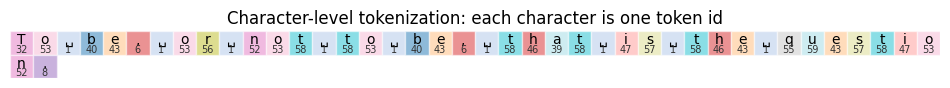

In [3]:
fig, ax = plt.subplots(figsize=(12, 1.5))
viz.show_tokenization("To be, or not to be, that is the question.", stoi, ax=ax)
ax.set_title("Character-level tokenization: each character is one token id")
plt.show()


## How often does each character appear?

Even before we train anything, the corpus has a clear fingerprint. The space character is by far the most common. Vowels dominate the letters. Uppercase letters are rare because they only appear at sentence starts and in speaker names. This is the statistical structure our model will have to learn — and, at first, the *only* structure it can use.


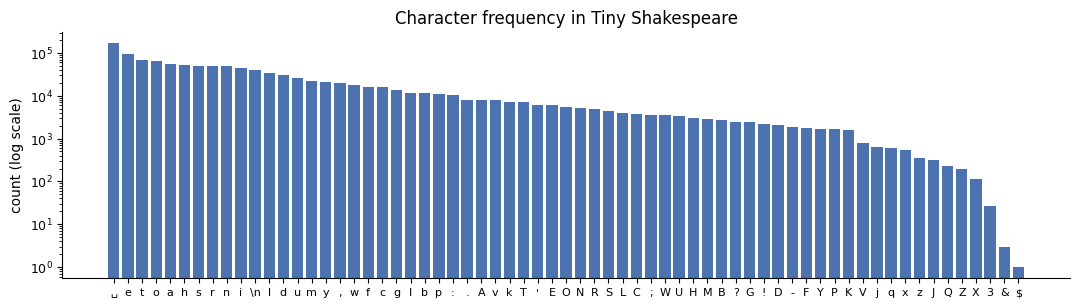

In [4]:
from collections import Counter
counts = Counter(text)
items = sorted(counts.items(), key=lambda kv: -kv[1])
labels = [viz._printable(c) for c, _ in items]
values = [c for _, c in items]

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.bar(range(len(values)), values, color="#4C72B0")
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title("Character frequency in Tiny Shakespeare")
plt.show()


## Train / validation split

One last piece of setup: we hold out the last 10% of the corpus as a **validation set** so we can tell whether the model is memorizing specific passages or learning general structure. We won't train on this slice.


In [5]:
import torch

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Total tokens:      {len(data):,}")
print(f"Train tokens:      {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")
print(f"\nFirst 40 train ids: {train_data[:40].tolist()}")
print(f"Decodes to:         {decode(train_data[:40].tolist())!r}")


Total tokens:      1,115,394
Train tokens:      1,003,854
Validation tokens: 111,540

First 40 train ids: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56]
Decodes to:         'First Citizen:\nBefore we proceed any fur'


## Map of the journey

Here is what the next four notebooks will do, and why.

| # | We'll build... | ...to feel |
|---|----------------|------------|
| **01** | A **bigram** model, first by counting, then by gradient descent. | That a neural net can learn the same statistics you'd compute by counting — and that seeing only one previous token is a hard ceiling. |
| **02** | A tiny **RNN** that carries a hidden state forward through the sequence. | Context helps — but RNNs are sequential (slow) and their gradients vanish across long distances. We need something better. |
| **03** | **Self-attention** from scratch: Q, K, V, masking, multiple heads, positional encodings. | The core innovation: every position can look at every other position directly, in parallel. This is the transformer's key idea. |
| **04** | A full **transformer block**: attention + residual + LayerNorm + MLP, stacked. | Why each piece is there. What the tensor shapes look like. How parameters are distributed. |
| **05** | A ~0.2 M-parameter **mini-GPT** trained on Shakespeare. | Watch samples evolve from random letters to Shakespeare-cadence. See how the little thing you built relates to the big things like Claude and GPT-4. |

Save this notebook. The corpus is ready, and so are we.

**Next up:** [01 — Bigram language models →](01_bigram_language_models.ipynb)
